# Introduction to Hierarchical Variational Inference

## Introduction

In this tutorial, we build and train a hierarchical variational inference (VI) model for the birds-16 dataset using PsiZ. The goal is to make the hierarchical construction concrete while keeping the behavioral task simple.

We will use a 2-rank-1 version of the birds dataset so we can focus on hierarchical VI details instead of trial-format complexity.

This tutorial covers:

1. Loading and inspecting the dataset.
2. Constructing hierarchy memberships for global, family, common-name, and leaf levels.
3. Building a hierarchical non-centered variational embedding with PsiZ builders.
4. Training and evaluating a stand-alone Keras model.
5. Visualizing learned representations across hierarchy levels.

## Preliminaries

```{note}
This notebook is stand-alone. It does not import or call psiz-phase-2 modules. We hard-code a temporary dataset path that points to a pre-converted 2-rank-1 snapshot.
```

```{warning}
The dataset location used here is provisional:

/home/brettroads/runtime/cache/1-projects/psiz-phase-2/checkpoints/birds/annotations/dataset/round_19

For long-term use, move this snapshot to a stable data location and update the constants below.
```

In [27]:
from pathlib import Path
import json

import keras
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psiz
import tensorflow as tf

In [28]:
matplotlib.rcParams['figure.dpi'] = 140

FP_ROUND = Path(
    '/home/brettroads/runtime/cache/1-projects/psiz-phase-2/checkpoints/'
    'birds/annotations/dataset/round_19'
)
FP_STIMULI = Path(
    '/home/brettroads/runtime/cache/1-projects/psiz-phase-2/checkpoints/'
    'birds/birds.csv'
)

# Set QUICK_RUN to False for a longer fit.
QUICK_RUN = False

## Why Hierarchical Non-Centered VI?

Hierarchical priors are useful because they let related stimuli share information. In birds-16, individual images can borrow statistical strength from common-name and family structure.

A practical issue appears when we use centered parameterizations in deep hierarchies: gradient updates can become poorly conditioned, especially when uncertainty parameters and latent location parameters are tightly coupled.

Non-centered parameterization rewrites latent variables as:

$$
z = \mu + \sigma \odot \epsilon
$$

where $\epsilon$ is learned in a standardized space. This often improves gradient flow and stabilizes optimization. In PsiZ, the hierarchical VI stack in this notebook uses non-centered variational components under the hood.

## Data Preparation

The round_19 snapshot is partitioned into train, validation, and test datasets. Each element is already formatted as a `(x, y, w)` tuple for training:

- `x['given2rank1_stimulus_set']`: three stimulus IDs per trial (query + 2 references).
- `y`: one-hot rank-1 choice target.
- `w`: sample weight.

In [29]:
def load_partition(fp_round: Path, split: str):
    fp_split = fp_round / split
    ds = tf.data.Dataset.load(str(fp_split))
    with open(fp_split / 'metadata.json', 'r', encoding='utf-8') as f:
        n_sample = int(json.load(f)['sample_count'])
    return ds, n_sample


ds_train_raw, n_sample_train = load_partition(FP_ROUND, 'train')
ds_val_raw, n_sample_val = load_partition(FP_ROUND, 'validation')
ds_test_raw, n_sample_test = load_partition(FP_ROUND, 'test')

print(f'train samples: {n_sample_train:,}')
print(f'validation samples: {n_sample_val:,}')
print(f'test samples: {n_sample_test:,}')

train samples: 5,223
validation samples: 787
test samples: 727


In [30]:
batch_size = 128

if QUICK_RUN:
    epochs = 20
    early_stop_patience = 5
else:
    epochs = 150
    early_stop_patience = 12

ds_train = ds_train_raw.shuffle(min(n_sample_train, 20000)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_val = ds_val_raw.batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test = ds_test_raw.batch(batch_size).prefetch(tf.data.AUTOTUNE)

first_sample = next(iter(ds_train_raw.take(1)))
print('sample tuple length:', len(first_sample))
print('input keys:', list(first_sample[0].keys()))
print('stimulus set shape:', first_sample[0]['given2rank1_stimulus_set'].shape)
print('target shape:', first_sample[1].shape)
print('sample weight shape:', first_sample[2].shape)

sample tuple length: 3
input keys: ['given2rank1_stimulus_set']
stimulus set shape: (3,)
target shape: (2,)
sample weight shape: ()


In [31]:
df_stimuli = pd.read_csv(FP_STIMULI, index_col=0)
df_stimuli = df_stimuli.sort_index()

# Convert hierarchy labels into contiguous integer IDs.
family_code, family_labels = pd.factorize(df_stimuli['taxonomic_family'])
common_code, common_labels = pd.factorize(df_stimuli['common_name'])
leaf_code = np.arange(len(df_stimuli), dtype=np.int32)
global_code = np.zeros(len(df_stimuli), dtype=np.int32)

memberships = np.stack(
    [global_code, family_code.astype(np.int32), common_code.astype(np.int32), leaf_code],
    axis=1,
).astype(np.int32)

n_stimuli = len(df_stimuli)
print('n_stimuli:', n_stimuli)
print('n_families:', len(family_labels))
print('n_common_names:', len(common_labels))
print('memberships shape:', memberships.shape)

df_stimuli.head()

n_stimuli: 208
n_families: 4
n_common_names: 16
memberships shape: (208, 4)


,filepath,common_name,taxonomic_family
1,birds_16/Cardinalidae/Blue_Grosbeak/Blue_Grosb...,Blue Grosbeak,Cardinalidae
2,birds_16/Cardinalidae/Blue_Grosbeak/Blue_Grosb...,Blue Grosbeak,Cardinalidae
3,birds_16/Cardinalidae/Blue_Grosbeak/Blue_Grosb...,Blue Grosbeak,Cardinalidae
4,birds_16/Cardinalidae/Blue_Grosbeak/Blue_Grosb...,Blue Grosbeak,Cardinalidae
5,birds_16/Cardinalidae/Blue_Grosbeak/Blue_Grosb...,Blue Grosbeak,Cardinalidae


## Model Construction

We now construct a four-level hierarchy:

1. Global.
2. Taxonomic family.
3. Common name.
4. Leaf (individual image).

The embedding stack is built with `build_hierarchical_vi_embedding`, which composes non-centered variational layers for non-root levels.

In [32]:
n_dim = 2
kl_scale = 1.0
learning_rate = 1e-3

hierarchy = psiz.keras.layers.HierarchySpec(
    levels=[
        psiz.keras.layers.HierarchyLevelSpec(
            role='global',
            membership_key=None,
            loc_trainable=False,
            scale_trainable=True,
            initialization=psiz.keras.layers.LevelInitializationMode.DEFAULT,
        ),
        psiz.keras.layers.HierarchyLevelSpec(
            role='taxonomic_family',
            membership_key='taxonomic_family',
            loc_trainable=True,
            scale_trainable=True,
            initialization=psiz.keras.layers.LevelInitializationMode.DEFAULT,
        ),
        psiz.keras.layers.HierarchyLevelSpec(
            role='common_name',
            membership_key='common_name',
            loc_trainable=True,
            scale_trainable=True,
            initialization=psiz.keras.layers.LevelInitializationMode.DEFAULT,
        ),
        psiz.keras.layers.HierarchyLevelSpec(
            role='leaf',
            membership_key='leaf',
            loc_trainable=True,
            scale_trainable=True,
            initialization=psiz.keras.layers.LevelInitializationMode.DEFAULT,
        ),
    ],
    mask_zero=True,
)

membership_input = psiz.keras.layers.MembershipInput(memberships=memberships)
posterior_factory = psiz.keras.layers.NonCenteredPosteriorFactory()

In [33]:
percept = psiz.keras.layers.build_hierarchical_vi_embedding(
    n_stimuli=n_stimuli,
    n_dim=n_dim,
    hierarchy=hierarchy,
    membership=membership_input,
    posterior_factory=posterior_factory,
    n_sample_train=n_sample_train,
    kl_scale=kl_scale,
    n_branch=1,
    kl_policy=psiz.keras.layers.KLWeightingPolicy.PER_SAMPLE_PER_BRANCH,
    kl_n_sample=30,
    scale_policy=psiz.keras.layers.ScaleInitializationPolicy.GEOMETRIC_DECAY,
    membership_source_policy=psiz.keras.layers.MembershipSourcePolicy.PRECOMPUTED,
    random_seed=123,
)

proximity = psiz.keras.layers.Minkowski(
    rho_initializer=keras.initializers.Constant(2.0),
    w_initializer=keras.initializers.Constant(1.0),
    activation=psiz.keras.layers.ExponentialSimilarity(
        beta_initializer=keras.initializers.Constant(10.0),
        tau_initializer=keras.initializers.Constant(1.0),
        gamma_initializer=keras.initializers.Constant(0.0),
        trainable=False,
    ),
)

softrank = psiz.keras.layers.SoftRank(n_select=1, trainable=False)


class Birds2Rank1Model(keras.Model):
    def __init__(self, percept=None, proximity=None, softrank=None, **kwargs):
        super().__init__(**kwargs)
        self.percept = percept
        self.proximity = proximity
        self.softrank = softrank
        self.stimuli_axis = 1

    def call(self, inputs):
        z = self.percept(inputs['given2rank1_stimulus_set'])
        z_q, z_r = keras.ops.split(z, [1], self.stimuli_axis)
        s = self.proximity([z_q, z_r])
        return self.softrank(s)


model = Birds2Rank1Model(percept=percept, proximity=proximity, softrank=softrank)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
    loss=keras.losses.CategoricalCrossentropy(),
    weighted_metrics=[keras.metrics.CategoricalCrossentropy(name='cce')],
)

model.summary()

Model: "birds2_rank1_model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_non_centered_variati… │ ?                      │           935 │
│ (EmbeddingNonCenteredVariation… │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ minkowski_2 (Minkowski)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ soft_rank_2 (SoftRank)          │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 937 (3.66 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 8 (32.00 B)

## Training

We use standard callback-based training with validation monitoring.

```{note}
If `QUICK_RUN=True`, this notebook uses fewer epochs and smaller patience for a smoke run. Set `QUICK_RUN=False` for a fuller fit.
```

In [34]:
from psiz.keras.callbacks import VariationalEarlyStopping

callbacks = [
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_cce',
        factor=0.5,
        patience=3,
        mode='min',
        min_delta=1e-4,
        min_lr=0.0,
        cooldown=0,
        verbose=1,
    ),
    VariationalEarlyStopping(
        monitor_cce='val_cce',
        monitor_elbo='val_loss',
        patience_cce=13,
        patience_elbo=17,
        verbose=1,
        epoch_start=0,
        min_delta=0.0,
        restore_best_weights=True,
    ),
]

history = model.fit(
    ds_train,
    validation_data=ds_val,
    epochs=epochs,
    callbacks=callbacks,
    verbose=2,
)

print('epochs completed:', len(history.history['loss']))

Epoch 1/150

Epoch 1: CCE wait=0/13, ELBO wait=0/17
41/41 - 2s - 57ms/step - cce: 0.6388 - loss: 0.7120 - val_cce: 0.5529 - val_loss: 0.6344 - learning_rate: 0.0010
Epoch 2/150

Epoch 2: CCE wait=0/13, ELBO wait=0/17
41/41 - 0s - 8ms/step - cce: 0.5317 - loss: 0.6095 - val_cce: 0.4695 - val_loss: 0.5537 - learning_rate: 0.0010
Epoch 3/150

Epoch 3: CCE wait=0/13, ELBO wait=0/17
41/41 - 0s - 9ms/step - cce: 0.4734 - loss: 0.5528 - val_cce: 0.4375 - val_loss: 0.5212 - learning_rate: 0.0010
Epoch 4/150

Epoch 4: CCE wait=0/13, ELBO wait=0/17
41/41 - 0s - 6ms/step - cce: 0.4458 - loss: 0.5246 - val_cce: 0.4286 - val_loss: 0.5100 - learning_rate: 0.0010
Epoch 5/150

Epoch 5: CCE wait=0/13, ELBO wait=0/17
41/41 - 0s - 11ms/step - cce: 0.4358 - loss: 0.5126 - val_cce: 0.4236 - val_loss: 0.5035 - learning_rate: 0.0010
Epoch 6/150

Epoch 6: CCE wait=0/13, ELBO wait=0/17
41/41 - 0s - 7ms/step - cce: 0.4243 - loss: 0.4995 - val_cce: 0.4191 - val_loss: 0.4966 - learning_rate: 0.0010
Epoch 7/150

E

## Evaluation

Now we evaluate the trained model on train, validation, and test splits.

In [35]:
metrics_train = model.evaluate(ds_train, return_dict=True, verbose=0)
metrics_val = model.evaluate(ds_val, return_dict=True, verbose=0)
metrics_test = model.evaluate(ds_test, return_dict=True, verbose=0)

results = pd.DataFrame([
    {'split': 'train', **metrics_train, 'n_sample': n_sample_train},
    {'split': 'validation', **metrics_val, 'n_sample': n_sample_val},
    {'split': 'test', **metrics_test, 'n_sample': n_sample_test},
])
results

,split,cce,loss,n_sample
0,train,0.393778,0.455102,5223
1,validation,0.426321,0.488599,787
2,test,0.456734,0.504959,727


## Model Analysis

We visualize all hierarchy levels of the learned representation:

1. Global level.
2. Taxonomic-family level.
3. Common-name level.
4. Leaf level (individual bird images).

Each point is shown with an HDI ellipse to communicate both estimated location and variance.

In [36]:
def _non_centered_core(layer):
    current = layer
    if hasattr(current, 'posterior'):
        current = current.posterior
    while hasattr(current, '_embedding'):
        current = current._embedding
    return current


def _diag_cov(scale):
    scale = keras.ops.convert_to_numpy(scale)
    return np.einsum('ni,ij->nij', scale ** 2, np.eye(scale.shape[-1], dtype=scale.dtype))


def _extract_level_params(model):
    level_names = ['leaf', 'common_name', 'taxonomic_family', 'global']
    params = {}

    current = model.percept
    i_level = 0
    while current is not None and i_level < len(level_names):
        name = level_names[i_level]
        core = _non_centered_core(current)
        loc = keras.ops.convert_to_numpy(core.loc)
        cov = _diag_cov(core.scale)

        if model.percept.mask_zero and loc.shape[0] > 1:
            loc = loc[1:]
            cov = cov[1:]

        params[name] = {'loc': loc, 'cov': cov}

        current = current.prior if hasattr(current, 'prior') else None
        i_level += 1

    return params


level_params = _extract_level_params(model)
for level_name in ['global', 'taxonomic_family', 'common_name', 'leaf']:
    print(
        level_name,
        'loc shape:', level_params[level_name]['loc'].shape,
        'cov shape:', level_params[level_name]['cov'].shape,
    )

global loc shape: (1, 2) cov shape: (1, 2, 2)
taxonomic_family loc shape: (4, 2) cov shape: (4, 2, 2)
common_name loc shape: (16, 2) cov shape: (16, 2, 2)
leaf loc shape: (208, 2) cov shape: (208, 2, 2)


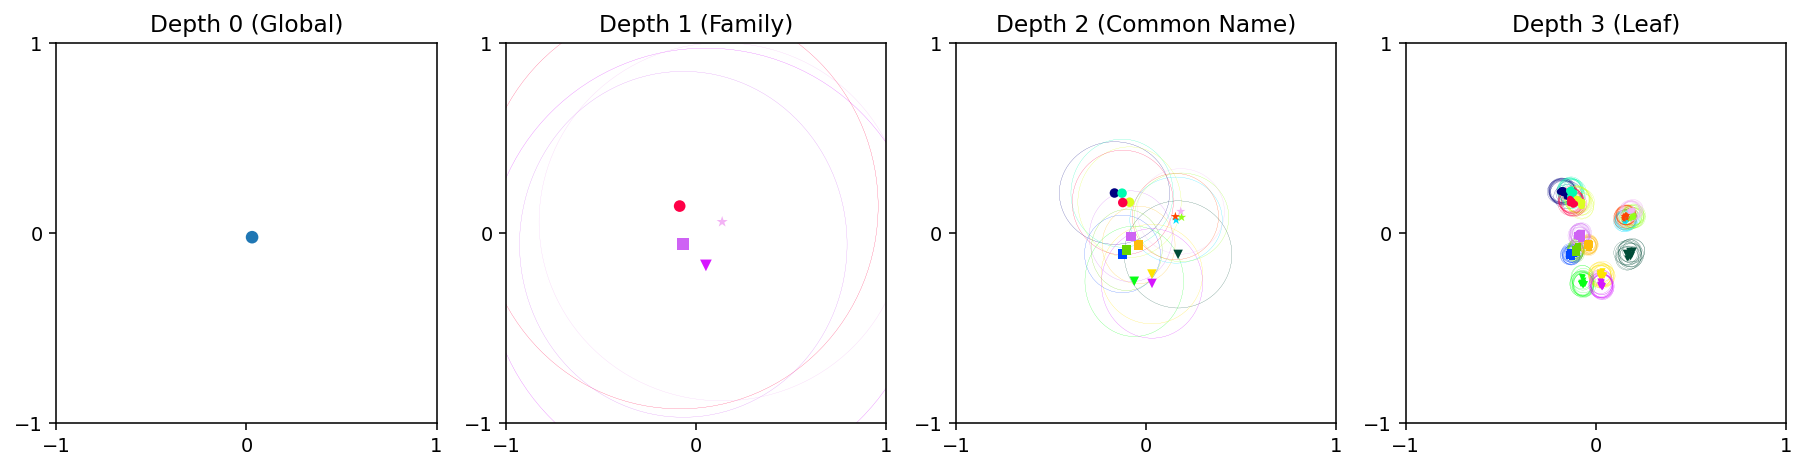

In [37]:
def bird_class_styling(df_stimuli):
    df_species = (
        df_stimuli[['common_name', 'taxonomic_family']]
        .drop_duplicates()
        .sort_values(['taxonomic_family', 'common_name'], ignore_index=True)
    )
    n_species = len(df_species)

    cmap = matplotlib.colormaps.get_cmap('gist_ncar')
    norm = matplotlib.colors.Normalize(vmin=0.0, vmax=n_species)
    species_color_arr = cmap(norm(range(n_species)))
    species_color_arr = species_color_arr[[0, 4, 8, 12, 1, 5, 9, 13, 2, 6, 10, 14, 3, 7, 11, 15]]

    family_marker_arr = [
        'o', 'o', 'o', 'o',
        'v', 'v', 'v', 'v',
        's', 's', 's', 's',
        '*', '*', '*', '*',
    ]

    class_styling = {}
    for idx, row in df_species.iterrows():
        class_styling[row['common_name']] = {
            'marker': family_marker_arr[idx],
            'color': species_color_arr[np.newaxis, idx],
        }

    for idx, row in df_species.iterrows():
        class_styling[row['taxonomic_family']] = {
            'marker': family_marker_arr[idx],
            'color': species_color_arr[np.newaxis, idx],
        }

    return class_styling


def _draw_leaf_level(ax, loc, cov, df_stimuli, df_species, class_styling, z_limits):
    for _, row in df_species.iterrows():
        common_name = row['common_name']
        bidx = (df_stimuli['common_name'] == common_name).values
        psiz.mplot.hdi_bvn(
            loc[bidx],
            cov[bidx],
            ax,
            p=0.99,
            edgecolor=class_styling[common_name]['color'],
            linewidth=0.1,
            fill=False,
        )
        ax.scatter(
            loc[bidx, 0],
            loc[bidx, 1],
            s=10,
            c=class_styling[common_name]['color'],
            marker=class_styling[common_name]['marker'],
            edgecolors='none',
            label=common_name,
            zorder=100,
        )
    ax.set_title('Depth 3 (Leaf)')
    ax.set_xlim(z_limits)
    ax.set_ylim(z_limits)


def _draw_common_level(ax, loc, cov, df_common_level, class_styling, z_limits):
    for idx, row in df_common_level.iterrows():
        common_name = row['common_name']
        psiz.mplot.hdi_bvn(
            loc[np.newaxis, idx],
            cov[np.newaxis, idx],
            ax,
            p=0.99,
            edgecolor=class_styling[common_name]['color'],
            linewidth=0.1,
            fill=False,
        )
        ax.scatter(
            loc[np.newaxis, idx, 0],
            loc[np.newaxis, idx, 1],
            s=24,
            c=class_styling[common_name]['color'],
            marker=class_styling[common_name]['marker'],
            edgecolors='none',
            zorder=100,
        )
    ax.set_title('Depth 2 (Common Name)')
    ax.set_xlim(z_limits)
    ax.set_ylim(z_limits)


def _draw_family_level(ax, loc, cov, df_family_level, class_styling, z_limits):
    for idx, row in df_family_level.iterrows():
        taxonomic_family = row['taxonomic_family']
        psiz.mplot.hdi_bvn(
            loc[np.newaxis, idx],
            cov[np.newaxis, idx],
            ax,
            p=0.99,
            edgecolor=class_styling[taxonomic_family]['color'],
            linewidth=0.1,
            fill=False,
        )
        ax.scatter(
            loc[np.newaxis, idx, 0],
            loc[np.newaxis, idx, 1],
            s=36,
            c=class_styling[taxonomic_family]['color'],
            marker=class_styling[taxonomic_family]['marker'],
            edgecolors='none',
            zorder=100,
        )
    ax.set_title('Depth 1 (Family)')
    ax.set_xlim(z_limits)
    ax.set_ylim(z_limits)


def _draw_global_level(ax, loc, cov, z_limits):
    psiz.mplot.hdi_bvn(
        loc[np.newaxis, 0],
        cov[np.newaxis, 0],
        ax,
        p=0.99,
        linewidth=0.2,
        fill=False,
    )
    ax.scatter(
        loc[np.newaxis, 0, 0],
        loc[np.newaxis, 0, 1],
        s=42,
        edgecolors='none',
        zorder=100,
    )
    ax.set_title('Depth 0 (Global)')
    ax.set_xlim(z_limits)
    ax.set_ylim(z_limits)


def _style_axis(ax):
    ax.set_aspect('equal')
    ax.set_xticks([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])


df_species = (
    df_stimuli[['common_name', 'taxonomic_family']]
    .drop_duplicates()
    .sort_values(['taxonomic_family', 'common_name'], ignore_index=True)
)

df_common_level = (
    pd.DataFrame({'common_name': common_labels})
    .merge(
        df_stimuli[['common_name', 'taxonomic_family']].drop_duplicates(),
        on='common_name',
        how='left',
    )
)

df_family_level = pd.DataFrame({'taxonomic_family': family_labels})

class_styling = bird_class_styling(df_stimuli)

leaf_loc = level_params['leaf']['loc']
loc_centering = np.mean(leaf_loc, axis=0, keepdims=True)

for name in level_params:
    level_params[name]['loc'] = level_params[name]['loc'] - loc_centering

z_max = 1.3 * np.max(np.abs(level_params['leaf']['loc']))
z_limits = [-z_max, z_max]

fig = plt.figure(figsize=(13.0, 3.4))
gs = fig.add_gridspec(1, 4)

ax0 = fig.add_subplot(gs[0, 0])
_draw_global_level(ax0, level_params['global']['loc'], level_params['global']['cov'], z_limits)
_style_axis(ax0)

ax1 = fig.add_subplot(gs[0, 1])
_draw_family_level(
    ax1,
    level_params['taxonomic_family']['loc'],
    level_params['taxonomic_family']['cov'],
    df_family_level,
    class_styling,
    z_limits,
)
_style_axis(ax1)

ax2 = fig.add_subplot(gs[0, 2])
_draw_common_level(
    ax2,
    level_params['common_name']['loc'],
    level_params['common_name']['cov'],
    df_common_level,
    class_styling,
    z_limits,
)
_style_axis(ax2)

ax3 = fig.add_subplot(gs[0, 3])
_draw_leaf_level(
    ax3,
    level_params['leaf']['loc'],
    level_params['leaf']['cov'],
    df_stimuli,
    df_species,
    class_styling,
    z_limits,
)
_style_axis(ax3)

fig.tight_layout()
plt.show()

## Summary

In this tutorial, we:

1. Loaded a round-partitioned 2-rank-1 birds dataset snapshot.
2. Built hierarchy memberships for global, family, common-name, and leaf levels.
3. Constructed a hierarchical non-centered variational embedding stack using PsiZ builders.
4. Trained and evaluated a stand-alone model.
5. Visualized multiple hierarchy levels.

The key modeling takeaway is that hierarchical VI is practical in PsiZ, and non-centered parameterization helps keep optimization stable by improving gradient behavior in deep hierarchical stacks.

## Exercises

TODO compare hierarchical and non-hierarchical solutions with different amounts of data